In [1]:
import os
import random
import numpy as np
import pandas as pd
from pprint import pprint

import torch
import torch.nn as nn
import torch.nn.functional as F

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    fbeta_score, roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score
)

print("Инициализация окружения...")

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
print(f"torch: {torch.__version__} | cuda: {torch.version.cuda}")


Инициализация окружения...
Используемое устройство: cpu
torch: 2.2.2 | cuda: None


# 1) Загрузка данных + построение графов


In [2]:
from graph import Graph, Node

ID_COL = "TransactionId"
Y_COL = "FraudResult"
TIME_COL = "TransactionStartTime"

CAT_COLS = [
    "BatchId", "AccountId", "SubscriptionId", "CustomerId",
    "CurrencyCode", "ProviderId", "ProductId", "ProductCategory", "ChannelId",
]
NUM_COLS = ["Amount", "Value", "CountryCode", "PricingStrategy"]

build_params = {"edge_keys": ["CustomerId"], "node_keys": ["ProductCategory"]}

def load_df(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Файл не найден: {csv_path}")
    df = pd.read_csv(csv_path)
    df[ID_COL] = df[ID_COL].astype("string")
    df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce").fillna(0).astype(int)
    return df

train_path = "train_raw.csv"
val_path = "val_raw.csv"
test_path = "test_raw.csv"

df_train = load_df(train_path)
df_val = load_df(val_path)
df_test = load_df(test_path)

print(f"Загружено: train={len(df_train)} | val={len(df_val)} | test={len(df_test)}")

print("Строим графы...")
graph_train = Graph(build_params); graph_train.build(df_train.to_dict("records"))
graph_val   = Graph(build_params); graph_val.build(df_val.to_dict("records"))
graph_test  = Graph(build_params); graph_test.build(df_test.to_dict("records"))
print("Графы построены!")


Загружено: train=54459 | val=21537 | test=19666
Строим графы...
Графы построены!


# 2) Кодирование транзакций


In [3]:
@dataclass
class TxEncoding:
    cat_maps: Dict[str, Dict[str, int]]
    num_mean: torch.Tensor
    num_std: torch.Tensor

def fit_tx_encoding(df: pd.DataFrame) -> TxEncoding:
    cat_maps: Dict[str, Dict[str, int]] = {}
    for c in CAT_COLS:
        vals = df[c].astype("string").fillna("__NA__")
        uniq = vals.unique().tolist()
        m = {"__UNK__": 0}
        for v in uniq:
            if v not in m:
                m[v] = len(m)
        cat_maps[c] = m

    num_t = torch.tensor(df[NUM_COLS].astype("float32").values, dtype=torch.float32)
    mean = num_t.mean(dim=0)
    std = num_t.std(dim=0).clamp(min=1e-6)
    return TxEncoding(cat_maps=cat_maps, num_mean=mean, num_std=std)

def transform_transactions(df: pd.DataFrame, enc: TxEncoding) -> Dict[str, torch.Tensor]:
    tx_ids = df[ID_COL].astype("string").tolist()
    y = torch.tensor(df[Y_COL].astype("float32").values, dtype=torch.float32)

    cats = []
    for c in CAT_COLS:
        vals = df[c].astype("string").fillna("__NA__").tolist()
        m = enc.cat_maps[c]
        cats.append(torch.tensor([m.get(v, 0) for v in vals], dtype=torch.long))
    x_cat = torch.stack(cats, dim=1)

    x_num = torch.tensor(df[NUM_COLS].astype("float32").values, dtype=torch.float32)
    x_num = (x_num - enc.num_mean) / enc.num_std

    t = pd.to_datetime(df[TIME_COL], errors="coerce", utc=True)
    hour = torch.tensor(t.dt.hour.fillna(0).astype("int64").values, dtype=torch.float32).unsqueeze(1) / 23.0
    dow = torch.tensor(t.dt.dayofweek.fillna(0).astype("int64").values, dtype=torch.float32).unsqueeze(1) / 6.0
    x_time = torch.cat([hour, dow], dim=1)

    return {"tx_ids": tx_ids, "x_cat": x_cat, "x_num": x_num, "x_time": x_time, "y": y}


# 3) Тензоры из графа


In [4]:
def build_tensors_from_graph(graph, tx_ids: List[str], use_node_size: bool = True) -> Dict[str, torch.Tensor]:
    nodes = graph.nodes
    node_ids = sorted(nodes.keys())
    id2idx = {nid: i for i, nid in enumerate(node_ids)}
    N = len(node_ids)

    src, dst = [], []
    for pid in node_ids:
        p = id2idx[pid]
        for cid in nodes[pid].children:
            if cid not in id2idx:
                continue
            c = id2idx[cid]
            src += [p, c]
            dst += [c, p]

    edge_index = torch.tensor([src, dst], dtype=torch.long) if len(src) else torch.zeros((2, 0), dtype=torch.long)

    if use_node_size:
        node_raw = torch.tensor([[float(nodes[nid].size)] for nid in node_ids], dtype=torch.float32)
    else:
        node_raw = torch.zeros((N, 1), dtype=torch.float32)

    tx_id2idx = {tid: i for i, tid in enumerate(tx_ids)}
    tx_node = torch.full((len(tx_ids),), -1, dtype=torch.long)

    for nid in node_ids:
        v = id2idx[nid]
        for tid in nodes[nid].transactions:
            if tid in tx_id2idx:
                tx_node[tx_id2idx[tid]] = v

    if (tx_node < 0).any():
        bad = [tx_ids[i] for i in torch.where(tx_node < 0)[0].tolist()[:20]]
        raise ValueError(f"Часть транзакций не нашлась в графе. Пример (до 20): {bad}")

    return {"edge_index": edge_index, "node_raw": node_raw, "tx_node": tx_node}

def scatter_mean(src: torch.Tensor, index: torch.Tensor, dim_size: int) -> torch.Tensor:
    out = torch.zeros((dim_size, src.size(1)), device=src.device, dtype=src.dtype)
    out.index_add_(0, index, src)

    cnt = torch.zeros((dim_size, 1), device=src.device, dtype=src.dtype)
    cnt.index_add_(0, index, torch.ones((index.size(0), 1), device=src.device, dtype=src.dtype))
    return out / cnt.clamp(min=1.0)


# 4) Модель


In [5]:
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        if edge_index.numel() == 0:
            return F.relu(self.lin_self(x))

        n = x.size(0)
        src, dst = edge_index[0], edge_index[1]

        neigh_sum = torch.zeros((n, x.size(1)), device=x.device, dtype=x.dtype)
        neigh_sum.index_add_(0, dst, x[src])

        deg = torch.zeros((n, 1), device=x.device, dtype=x.dtype)
        deg.index_add_(0, dst, torch.ones((dst.size(0), 1), device=x.device, dtype=x.dtype))
        neigh_mean = neigh_sum / deg.clamp(min=1.0)

        return F.relu(self.lin_self(x) + self.lin_neigh(neigh_mean))

class TxEncoder(nn.Module):
    def __init__(self, cat_cardinalities: List[int], num_dim: int, time_dim: int,
                 emb_dim: int = 16, hidden: int = 64):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(card, emb_dim) for card in cat_cardinalities])

        in_dim = len(cat_cardinalities) * emb_dim + num_dim + time_dim
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )

    def forward(self, x_cat: torch.Tensor, x_num: torch.Tensor, x_time: torch.Tensor) -> torch.Tensor:
        e = [emb(x_cat[:, i]) for i, emb in enumerate(self.embs)]
        return self.mlp(torch.cat(e + [x_num, x_time], dim=1))

class FraudTreeModel(nn.Module):
    def __init__(self,
                 cat_cardinalities: List[int],
                 node_raw_dim: int,
                 num_dim: int,
                 time_dim: int,
                 hidden: int = 64,
                 gnn_layers: int = 2):
        super().__init__()
        self.tx_enc = TxEncoder(cat_cardinalities, num_dim, time_dim, emb_dim=16, hidden=hidden)
        self.node_enc = nn.Sequential(nn.Linear(node_raw_dim, hidden), nn.ReLU())
        self.node_fuse = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.ReLU())
        self.gnn = nn.ModuleList([GraphSAGELayer(hidden, hidden) for _ in range(gnn_layers)])
        self.tx_head = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))

    def forward(self, edge_index, node_raw, tx_node, x_cat, x_num, x_time):
        e_tx = self.tx_enc(x_cat, x_num, x_time)

        N = node_raw.size(0)
        node_from_tx = scatter_mean(e_tx, tx_node, dim_size=N)
        node_raw_emb = self.node_enc(node_raw)
        h = self.node_fuse(torch.cat([node_from_tx, node_raw_emb], dim=1))

        for layer in self.gnn:
            h = layer(h, edge_index)

        logits = self.tx_head(torch.cat([e_tx, h[tx_node]], dim=1)).squeeze(1)
        return logits


# 5) Метрики + графики

Напишем функции для вычисления метрик и построения графиков.

In [6]:
def compute_metrics_np(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= float(threshold)).astype(int)

    out = {
        "F2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
        "F0.5": float(fbeta_score(y_true, y_pred, beta=0.5, zero_division=0)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
    }

    if len(np.unique(y_true)) == 2:
        out["ROC-AUC"] = float(roc_auc_score(y_true, y_prob))
        out["PR-AUC"] = float(average_precision_score(y_true, y_prob))
    else:
        out["ROC-AUC"] = float("nan")
        out["PR-AUC"] = float("nan")

    return out

def select_best_threshold_by_f05(y_true: np.ndarray, y_prob: np.ndarray, thr_grid: np.ndarray) -> Tuple[float, float]:
    best_thr = float(thr_grid[0])
    best_f05 = -1.0
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    for thr in thr_grid:
        y_pred = (y_prob >= float(thr)).astype(int)
        f05 = fbeta_score(y_true, y_pred, beta=0.5, zero_division=0)
        if f05 > best_f05:
            best_f05 = float(f05)
            best_thr = float(thr)

    return best_thr, best_f05

def plot_val_history(history: Dict[str, List[float]]):
    epochs = np.arange(1, len(history["val_loss"]) + 1)

    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.ravel()

    def _plot(ax, y, title, y2=None, label1="val", label2=None):
        ax.plot(epochs, y, label=label1)
        if y2 is not None:
            ax.plot(epochs, y2, label=label2)
        ax.set_title(title)
        ax.set_xlabel("Эпоха")
        ax.grid(True)
        if y2 is not None:
            ax.legend()

    _plot(axes[0], history["train_loss"], "Loss (train vs val)", y2=history["val_loss"], label1="train", label2="val")

    _plot(axes[1], history["val_F2"], "F2 (val)")
    _plot(axes[2], history["val_F0.5"], "F0.5 (val)")

    _plot(axes[3], history["val_Precision"], "Precision (val)")
    _plot(axes[4], history["val_Recall"], "Recall (val)")
    _plot(axes[5], history["val_Accuracy"], "Accuracy (val)")

    _plot(axes[6], history["val_ROC-AUC"], "ROC-AUC (val)")
    _plot(axes[7], history["val_PR-AUC"], "PR-AUC (val)")
    _plot(axes[8], history["val_thr_used"], "Threshold (fixed from val-grid)")

    plt.tight_layout()
    plt.show()


# 6) Обучение (по lr) + явный перебор threshold на валидации


In [7]:
def reset_seed(seed_value: int = 42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)

def make_pack(
    df: pd.DataFrame,
    graph,
    enc: TxEncoding,
    device: torch.device
) -> Tuple[Dict[str, torch.Tensor], List[str], np.ndarray]:
    tr = transform_transactions(df, enc)
    gt = build_tensors_from_graph(graph, tr["tx_ids"], use_node_size=True)

    pack = {
        "edge_index": gt["edge_index"].to(device),
        "node_raw": gt["node_raw"].to(device),
        "tx_node": gt["tx_node"].to(device),
        "x_cat": tr["x_cat"].to(device),
        "x_num": tr["x_num"].to(device),
        "x_time": tr["x_time"].to(device),
        "y": tr["y"].to(device),
    }
    y_np = tr["y"].cpu().numpy().astype(int)
    return pack, tr["tx_ids"], y_np

@torch.no_grad()
def predict_val_prob(model: nn.Module, pack: Dict[str, torch.Tensor]) -> np.ndarray:
    model.eval()
    logits = model(
        pack["edge_index"], pack["node_raw"], pack["tx_node"],
        pack["x_cat"], pack["x_num"], pack["x_time"]
    )
    return torch.sigmoid(logits).detach().cpu().numpy()

def train_one_lr(
    df_train: pd.DataFrame, graph_train,
    df_val: pd.DataFrame, graph_val,
    device: torch.device,
    lr: float,
    epochs: int,
    hidden: int,
    gnn_layers: int,
) -> Dict[str, object]:
    enc = fit_tx_encoding(df_train)
    tr_pack, _, _ = make_pack(df_train, graph_train, enc, device)
    va_pack, _, y_val_np = make_pack(df_val, graph_val, enc, device)

    cat_cardinalities = [len(enc.cat_maps[c]) for c in CAT_COLS]
    model = FraudTreeModel(
        cat_cardinalities=cat_cardinalities,
        node_raw_dim=tr_pack["node_raw"].size(1),
        num_dim=tr_pack["x_num"].size(1),
        time_dim=tr_pack["x_time"].size(1),
        hidden=hidden,
        gnn_layers=gnn_layers,
    ).to(device)

    y_tr = tr_pack["y"]
    n_pos = float(y_tr.sum().item())
    n_neg = float(y_tr.numel() - y_tr.sum().item())
    pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_ROC-AUC": [],
        "val_PR-AUC": [],
        "val_prob_by_epoch": [],
    }

    best_epoch = -1
    best_score = -np.inf
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        logits_tr = model(
            tr_pack["edge_index"], tr_pack["node_raw"], tr_pack["tx_node"],
            tr_pack["x_cat"], tr_pack["x_num"], tr_pack["x_time"]
        )
        loss_tr = criterion(logits_tr, tr_pack["y"])

        optimizer.zero_grad()
        loss_tr.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_va = model(
                va_pack["edge_index"], va_pack["node_raw"], va_pack["tx_node"],
                va_pack["x_cat"], va_pack["x_num"], va_pack["x_time"]
            )
            loss_va = float(criterion(logits_va, va_pack["y"]).item())
            prob_va = torch.sigmoid(logits_va).detach().cpu().numpy()

        if len(np.unique(y_val_np)) == 2:
            roc = float(roc_auc_score(y_val_np, prob_va))
            pr = float(average_precision_score(y_val_np, prob_va))
        else:
            roc, pr = float("nan"), float("nan")

        history["train_loss"].append(float(loss_tr.item()))
        history["val_loss"].append(loss_va)
        history["val_ROC-AUC"].append(roc)
        history["val_PR-AUC"].append(pr)
        history["val_prob_by_epoch"].append(prob_va.astype(np.float32))

        score = pr if not np.isnan(pr) else -np.inf
        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch == 1 or epoch % 10 == 0:
            print(f"lr={lr:.1e} | эпоха [{epoch:03d}/{epochs}] loss_tr={loss_tr.item():.6f} loss_val={loss_va:.6f} PR-AUC={pr:.6f}")

    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return {
        "lr": lr,
        "enc": enc,
        "best_epoch": best_epoch,
        "best_state": best_state,
        "history": history,
        "y_val_np": y_val_np,
    }

def eval_model_on_test(
    model: nn.Module,
    enc: TxEncoding,
    df_test: pd.DataFrame,
    graph_test,
    device: torch.device
) -> pd.DataFrame:
    te = transform_transactions(df_test, enc)
    gte = build_tensors_from_graph(graph_test, te["tx_ids"], use_node_size=True)

    pack = {
        "edge_index": gte["edge_index"].to(device),
        "node_raw": gte["node_raw"].to(device),
        "tx_node": gte["tx_node"].to(device),
        "x_cat": te["x_cat"].to(device),
        "x_num": te["x_num"].to(device),
        "x_time": te["x_time"].to(device),
    }

    model.eval()
    with torch.no_grad():
        logits = model(pack["edge_index"], pack["node_raw"], pack["tx_node"], pack["x_cat"], pack["x_num"], pack["x_time"])
        prob = torch.sigmoid(logits).detach().cpu().numpy()

    out = df_test[[ID_COL, Y_COL]].copy()
    out["fraud_prob"] = prob
    return out

def compute_customer_level_metrics(df_test_merged: pd.DataFrame, threshold: float) -> Dict[str, float]:
    g = (df_test_merged.groupby("CustomerId", as_index=False)
         .agg(FraudResult=(Y_COL, "max"), fraud_prob=("fraud_prob", "max")))

    y_true = g["FraudResult"].astype(int).values
    y_prob = g["fraud_prob"].astype(float).values
    y_pred = (y_prob >= float(threshold)).astype(int)

    out = {
        "F2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
        "F0.5": float(fbeta_score(y_true, y_pred, beta=0.5, zero_division=0)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
    }

    if len(np.unique(y_true)) == 2:
        out["ROC-AUC"] = float(roc_auc_score(y_true, y_prob))
        out["PR-AUC"] = float(average_precision_score(y_true, y_prob))
    else:
        out["ROC-AUC"] = float("nan")
        out["PR-AUC"] = float("nan")

    return out


# 7) Базовая модель

Построим эксперимент с базовой версией моделью, а потом пойдем перебирать гиперпараметры.

In [8]:
epochs = 125
hidden = 64
gnn_layers = 2

lr = 0.001
thr = 0.5

out_lr = train_one_lr(
    df_train=df_train, graph_train=graph_train,
    df_val=df_val, graph_val=graph_val,
    device=device,
    lr=lr,
    epochs=epochs,
    hidden=hidden,
    gnn_layers=gnn_layers
)

y_val_np = out_lr["y_val_np"]
best_epoch = int(out_lr["best_epoch"])
prob_val_best_epoch = out_lr["history"]["val_prob_by_epoch"][best_epoch - 1]

m = compute_metrics_np(y_val_np, prob_val_best_epoch, threshold=float(thr))

print('Results with lr={:.3f}, thr={:.2f}:'.format(lr, thr))
pprint(m)

lr=1.0e-03 | эпоха [001/125] loss_tr=1.718441 loss_val=1.518931 PR-AUC=0.061539
lr=1.0e-03 | эпоха [010/125] loss_tr=1.033453 loss_val=1.328284 PR-AUC=0.358583
lr=1.0e-03 | эпоха [020/125] loss_tr=0.629487 loss_val=1.012193 PR-AUC=0.516110
lr=1.0e-03 | эпоха [030/125] loss_tr=0.237718 loss_val=1.337977 PR-AUC=0.524881
lr=1.0e-03 | эпоха [040/125] loss_tr=0.112154 loss_val=1.480810 PR-AUC=0.512457
lr=1.0e-03 | эпоха [050/125] loss_tr=0.064486 loss_val=1.247354 PR-AUC=0.485955
lr=1.0e-03 | эпоха [060/125] loss_tr=0.038598 loss_val=1.112252 PR-AUC=0.488440
lr=1.0e-03 | эпоха [070/125] loss_tr=0.020990 loss_val=1.606810 PR-AUC=0.487115
lr=1.0e-03 | эпоха [080/125] loss_tr=0.015199 loss_val=1.869951 PR-AUC=0.490183
lr=1.0e-03 | эпоха [090/125] loss_tr=0.012802 loss_val=2.054397 PR-AUC=0.477277
lr=1.0e-03 | эпоха [100/125] loss_tr=0.011400 loss_val=2.122702 PR-AUC=0.518929
lr=1.0e-03 | эпоха [110/125] loss_tr=0.010502 loss_val=2.183901 PR-AUC=0.525778
lr=1.0e-03 | эпоха [120/125] loss_tr=0.0

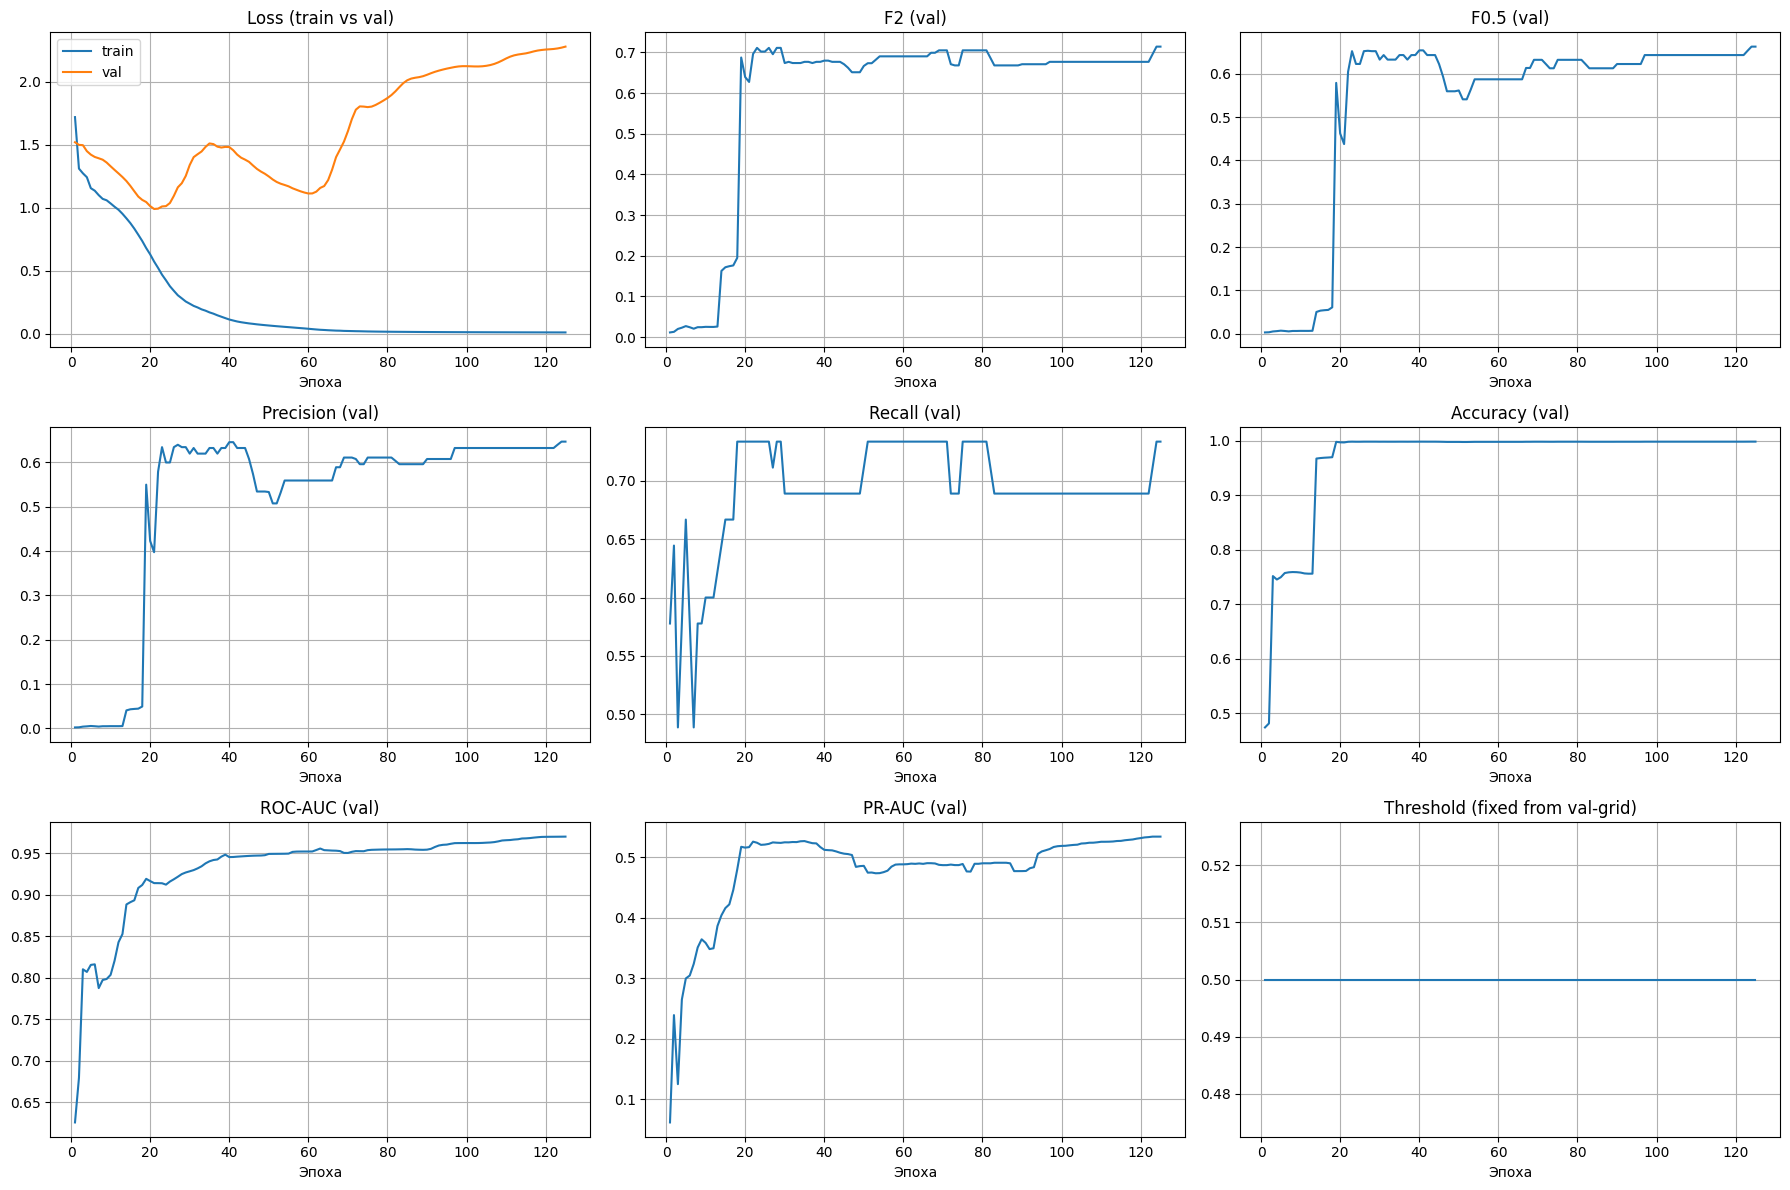


Метрики на уровне транзакций:
  threshold : 0.500000
  F2       : 0.480769
  F0.5     : 0.735294
  Precision: 0.892857
  Recall   : 0.431034
  Accuracy : 0.998169
  ROC-AUC  : 0.695473
  PR-AUC   : 0.518074

Метрики на уровне CustomerId:
  F2       : 0.500000
  F0.5     : 0.800000
  Precision: 1.000000
  Recall   : 0.444444
  Accuracy : 0.993324
  ROC-AUC  : 0.616517
  PR-AUC   : 0.460166


In [9]:
hist_raw = out_lr['history']

history = {
    "train_loss": hist_raw["train_loss"],
    "val_loss": hist_raw["val_loss"],
    "val_ROC-AUC": hist_raw["val_ROC-AUC"],
    "val_PR-AUC": hist_raw["val_PR-AUC"],
    "val_thr_used": [thr] * len(hist_raw["val_loss"]),
    "val_F2": [],
    "val_F0.5": [],
    "val_Precision": [],
    "val_Recall": [],
    "val_Accuracy": [],
}

for prob_va in hist_raw["val_prob_by_epoch"]:
    m = compute_metrics_np(y_val_np, prob_va, threshold=thr)
    history["val_F2"].append(m["F2"])
    history["val_F0.5"].append(m["F0.5"])
    history["val_Precision"].append(m["Precision"])
    history["val_Recall"].append(m["Recall"])
    history["val_Accuracy"].append(m["Accuracy"])

plot_val_history(history)

enc = fit_tx_encoding(df_train)
tr_pack, _, _ = make_pack(df_train, graph_train, enc, device)
va_pack, _, y_val_np = make_pack(df_val, graph_val, enc, device)

cat_cardinalities = [len(enc.cat_maps[c]) for c in CAT_COLS]
model = FraudTreeModel(
    cat_cardinalities=cat_cardinalities,
    node_raw_dim=tr_pack["node_raw"].size(1),
    num_dim=tr_pack["x_num"].size(1),
    time_dim=tr_pack["x_time"].size(1),
    hidden=hidden,
    gnn_layers=gnn_layers,
).to(device)

scored_test = eval_model_on_test(model,enc, df_test, graph_test, device=device)

df_test_merged = df_test.merge(
    scored_test[[ID_COL, "fraud_prob"]],
    on=ID_COL, how="left", validate="one_to_one"
)

if df_test_merged["fraud_prob"].isna().any():
    raise ValueError("Есть TransactionId без fraud_prob после merge")

df_test_merged["fraud_pred"] = (df_test_merged["fraud_prob"] >= thr).astype("int64")

tx_metrics = compute_metrics_np(
    y_true=df_test_merged[Y_COL].astype(int).values,
    y_prob=df_test_merged["fraud_prob"].astype(float).values,
    threshold=thr
)
cust_metrics = compute_customer_level_metrics(df_test_merged, threshold=thr)

print("\nМетрики на уровне транзакций:")
print(f"  threshold : {thr:.6f}")
for k in ["F2", "F0.5", "Precision", "Recall", "Accuracy", "ROC-AUC", "PR-AUC"]:
    print(f"  {k:9s}: {tx_metrics[k]:.6f}")

print("\nМетрики на уровне CustomerId:")
for k in ["F2", "F0.5", "Precision", "Recall", "Accuracy", "ROC-AUC", "PR-AUC"]:
    print(f"  {k:9s}: {cust_metrics[k]:.6f}")

In [10]:
thr = 0.85

out_lr = train_one_lr(
    df_train=df_train, graph_train=graph_train,
    df_val=df_val, graph_val=graph_val,
    device=device,
    lr=lr,
    epochs=epochs,
    hidden=hidden,
    gnn_layers=gnn_layers
)

y_val_np = out_lr["y_val_np"]
best_epoch = int(out_lr["best_epoch"])
prob_val_best_epoch = out_lr["history"]["val_prob_by_epoch"][best_epoch - 1]

m = compute_metrics_np(y_val_np, prob_val_best_epoch, threshold=float(thr))

print('Results with lr={:.3f}, thr={:.2f}:'.format(lr, thr))
pprint(m)

lr=1.0e-03 | эпоха [001/125] loss_tr=1.605698 loss_val=1.548189 PR-AUC=0.003372
lr=1.0e-03 | эпоха [010/125] loss_tr=1.039260 loss_val=1.298017 PR-AUC=0.342757
lr=1.0e-03 | эпоха [020/125] loss_tr=0.613867 loss_val=0.817078 PR-AUC=0.491045
lr=1.0e-03 | эпоха [030/125] loss_tr=0.200114 loss_val=0.370103 PR-AUC=0.581517
lr=1.0e-03 | эпоха [040/125] loss_tr=0.097951 loss_val=0.254760 PR-AUC=0.635549
lr=1.0e-03 | эпоха [050/125] loss_tr=0.058353 loss_val=0.430687 PR-AUC=0.560950
lr=1.0e-03 | эпоха [060/125] loss_tr=0.030304 loss_val=0.540465 PR-AUC=0.544301
lr=1.0e-03 | эпоха [070/125] loss_tr=0.018054 loss_val=1.102255 PR-AUC=0.503260
lr=1.0e-03 | эпоха [080/125] loss_tr=0.013772 loss_val=1.461874 PR-AUC=0.503262
lr=1.0e-03 | эпоха [090/125] loss_tr=0.011715 loss_val=1.760861 PR-AUC=0.493275
lr=1.0e-03 | эпоха [100/125] loss_tr=0.010572 loss_val=1.973691 PR-AUC=0.469349
lr=1.0e-03 | эпоха [110/125] loss_tr=0.009824 loss_val=2.162030 PR-AUC=0.476173
lr=1.0e-03 | эпоха [120/125] loss_tr=0.0

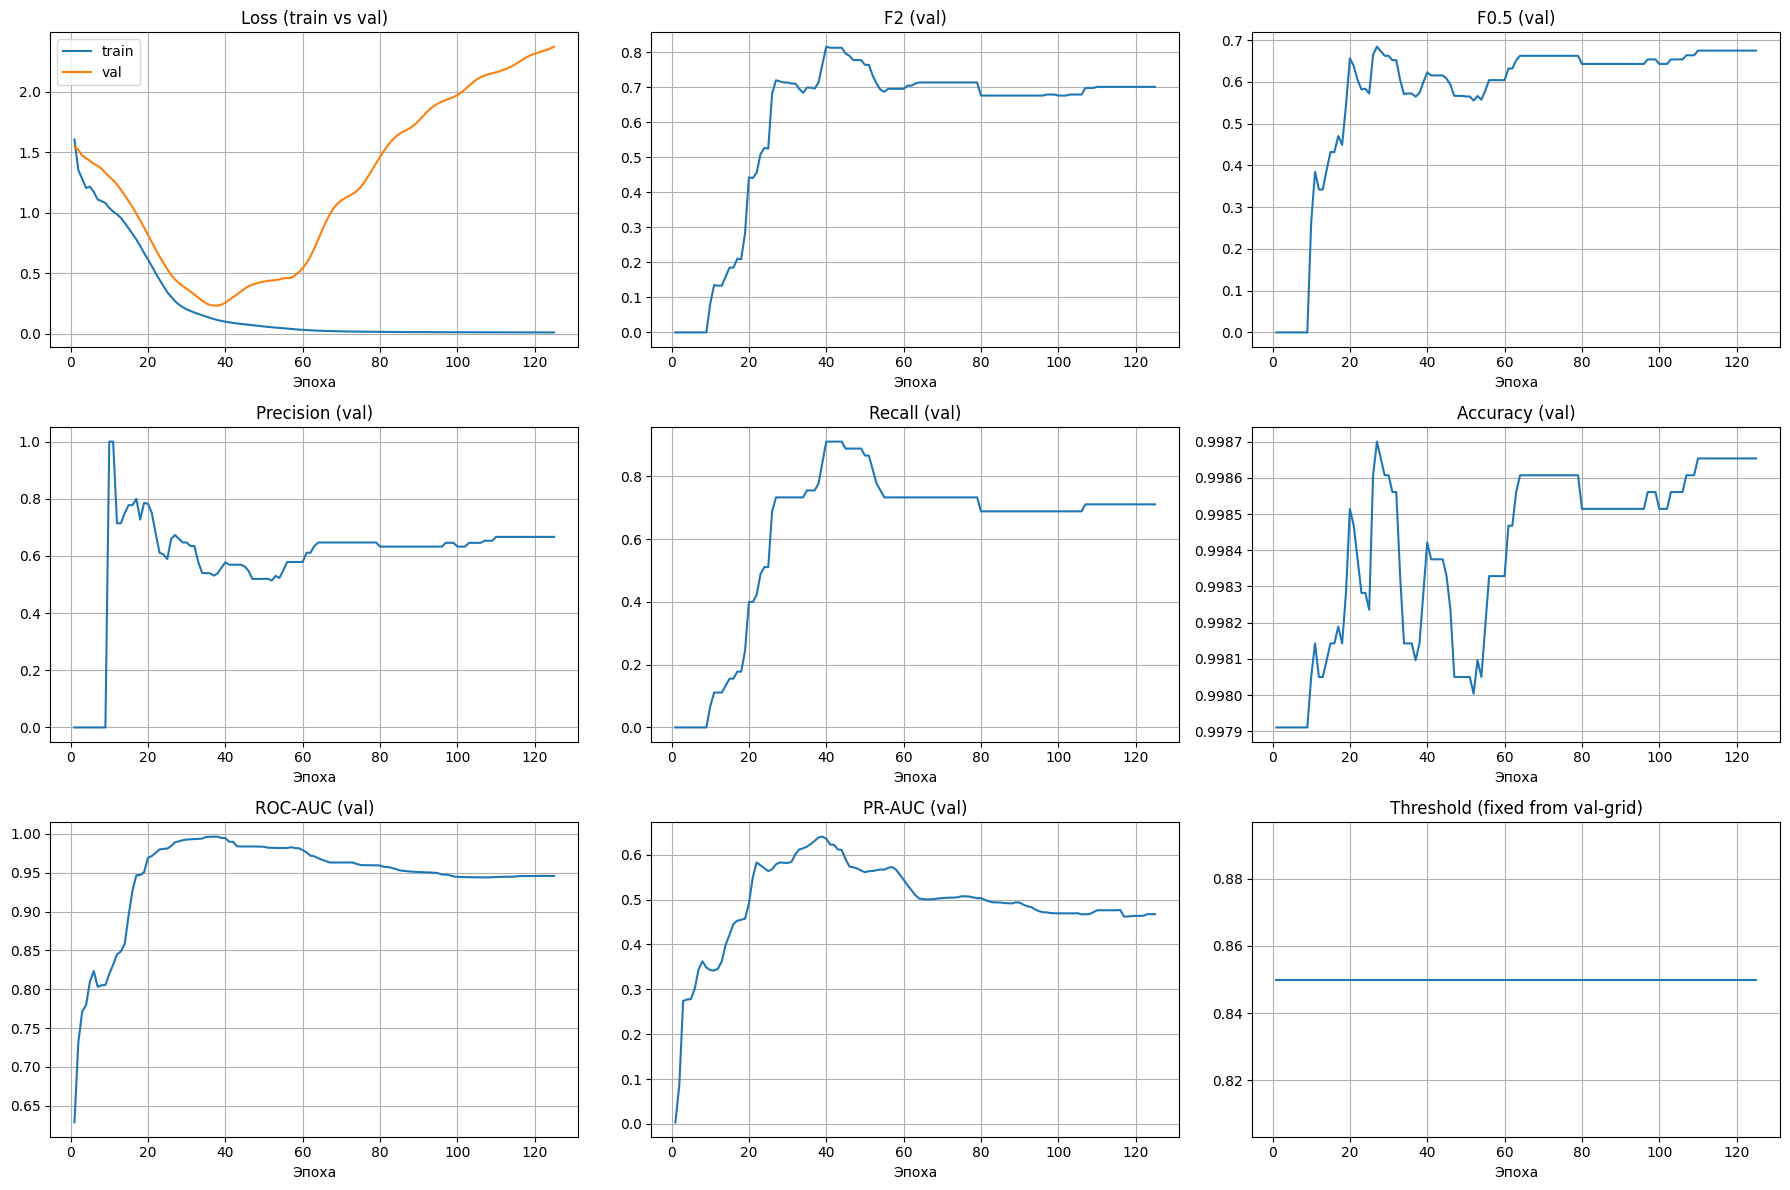


Метрики на уровне транзакций:
  threshold : 0.850000
  F2       : 0.043956
  F0.5     : 0.014440
  Precision: 0.011799
  Recall   : 0.137931
  Accuracy : 0.963389
  ROC-AUC  : 0.872242
  PR-AUC   : 0.116479

Метрики на уровне CustomerId:
  F2       : 0.042135
  F0.5     : 0.011637
  Precision: 0.009375
  Recall   : 0.333333
  Accuracy : 0.568758
  ROC-AUC  : 0.610511
  PR-AUC   : 0.125955


In [11]:
hist_raw = out_lr['history']

history = {
    "train_loss": hist_raw["train_loss"],
    "val_loss": hist_raw["val_loss"],
    "val_ROC-AUC": hist_raw["val_ROC-AUC"],
    "val_PR-AUC": hist_raw["val_PR-AUC"],
    "val_thr_used": [thr] * len(hist_raw["val_loss"]),
    "val_F2": [],
    "val_F0.5": [],
    "val_Precision": [],
    "val_Recall": [],
    "val_Accuracy": [],
}

for prob_va in hist_raw["val_prob_by_epoch"]:
    m = compute_metrics_np(y_val_np, prob_va, threshold=thr)
    history["val_F2"].append(m["F2"])
    history["val_F0.5"].append(m["F0.5"])
    history["val_Precision"].append(m["Precision"])
    history["val_Recall"].append(m["Recall"])
    history["val_Accuracy"].append(m["Accuracy"])

plot_val_history(history)

enc = fit_tx_encoding(df_train)
tr_pack, _, _ = make_pack(df_train, graph_train, enc, device)
va_pack, _, y_val_np = make_pack(df_val, graph_val, enc, device)

cat_cardinalities = [len(enc.cat_maps[c]) for c in CAT_COLS]
model = FraudTreeModel(
    cat_cardinalities=cat_cardinalities,
    node_raw_dim=tr_pack["node_raw"].size(1),
    num_dim=tr_pack["x_num"].size(1),
    time_dim=tr_pack["x_time"].size(1),
    hidden=hidden,
    gnn_layers=gnn_layers,
).to(device)

scored_test = eval_model_on_test(model,enc, df_test, graph_test, device=device)

df_test_merged = df_test.merge(
    scored_test[[ID_COL, "fraud_prob"]],
    on=ID_COL, how="left", validate="one_to_one"
)

if df_test_merged["fraud_prob"].isna().any():
    raise ValueError("Есть TransactionId без fraud_prob после merge")

df_test_merged["fraud_pred"] = (df_test_merged["fraud_prob"] >= thr).astype("int64")

tx_metrics = compute_metrics_np(
    y_true=df_test_merged[Y_COL].astype(int).values,
    y_prob=df_test_merged["fraud_prob"].astype(float).values,
    threshold=thr
)
cust_metrics = compute_customer_level_metrics(df_test_merged, threshold=thr)

print("\nМетрики на уровне транзакций:")
print(f"  threshold : {thr:.6f}")
for k in ["F2", "F0.5", "Precision", "Recall", "Accuracy", "ROC-AUC", "PR-AUC"]:
    print(f"  {k:9s}: {tx_metrics[k]:.6f}")

print("\nМетрики на уровне CustomerId:")
for k in ["F2", "F0.5", "Precision", "Recall", "Accuracy", "ROC-AUC", "PR-AUC"]:
    print(f"  {k:9s}: {cust_metrics[k]:.6f}")

Мы изучили базовое поведение нашей модельки, все идет в правильном направлении. Теперь, опираясь на валидационную выборку, давайте переберем и оставим лучшие гиперпараметры – `trashhold` и `learning rate`!

# 8) Явный grid search по (lr, threshold) + графики по всем метрикам (на лучшей паре)


In [ ]:
epochs = 125
hidden = 64
gnn_layers = 2

lr_grid = np.linspace(0.001, 0.1, 10)
thr_grid = np.linspace(0.01, 0.99, 99)

results_rows = []

best_pair = {
    "val_F0.5": -np.inf,
    "lr": None,
    "thr": None,
    "enc": None,
    "state": None,
    "history_raw": None,
    "y_val_np": None,
    "best_epoch": None,
}

print("Запускаем grid search по lr и threshold...")

for lr in tqdm(lr_grid):
    reset_seed(seed)

    out_lr = train_one_lr(
        df_train=df_train, graph_train=graph_train,
        df_val=df_val, graph_val=graph_val,
        device=device,
        lr=lr,
        epochs=epochs,
        hidden=hidden,
        gnn_layers=gnn_layers
    )

    y_val_np = out_lr["y_val_np"]
    best_epoch = int(out_lr["best_epoch"])
    prob_val_best_epoch = out_lr["history"]["val_prob_by_epoch"][best_epoch - 1]

    for thr in thr_grid:
        m = compute_metrics_np(y_val_np, prob_val_best_epoch, threshold=float(thr))
        results_rows.append({
            "lr": float(lr),
            "thr": float(thr),
            "val_F0.5": m["F0.5"],
            "val_F2": m["F2"],
            "val_Precision": m["Precision"],
            "val_Recall": m["Recall"],
            "val_Accuracy": m["Accuracy"],
            "best_epoch_by_PR_AUC": best_epoch,
            "val_ROC-AUC(best_epoch)": out_lr["history"]["val_ROC-AUC"][best_epoch - 1],
            "val_PR-AUC(best_epoch)": out_lr["history"]["val_PR-AUC"][best_epoch - 1],
        })

        if m["F0.5"] > best_pair["val_F0.5"]:
            best_pair.update({
                "val_F0.5": m["F0.5"],
                "lr": float(lr),
                "thr": float(thr),
                "enc": out_lr["enc"],
                "state": out_lr["best_state"],
                "history_raw": out_lr["history"],
                "y_val_np": y_val_np,
                "best_epoch": best_epoch,
            })

results = pd.DataFrame(results_rows).sort_values(["val_F0.5"], ascending=False).reset_index(drop=True)

print("\nТоп-10 (lr, thr) по val_F0.5:")
display(results.head(10))

print("\nЛучшая пара:")
print(f"  lr={best_pair['lr']:.1e}")
print(f"  thr={best_pair['thr']:.4f}")
print(f"  val_F0.5={best_pair['val_F0.5']:.6f}")
print(f"  epoch(best by PR-AUC)={best_pair['best_epoch']}")


Запускаем grid search по lr и threshold...


  0%|          | 0/10 [00:00<?, ?it/s]

lr=1.0e-03 | эпоха [001/125] loss_tr=1.718441 loss_val=1.518931 PR-AUC=0.061544
lr=1.0e-03 | эпоха [010/125] loss_tr=1.033453 loss_val=1.328284 PR-AUC=0.358583
lr=1.0e-03 | эпоха [020/125] loss_tr=0.629487 loss_val=1.012192 PR-AUC=0.516110
lr=1.0e-03 | эпоха [030/125] loss_tr=0.237718 loss_val=1.338007 PR-AUC=0.524881
lr=1.0e-03 | эпоха [040/125] loss_tr=0.112185 loss_val=1.476628 PR-AUC=0.512458
lr=1.0e-03 | эпоха [050/125] loss_tr=0.064602 loss_val=1.238354 PR-AUC=0.486569
lr=1.0e-03 | эпоха [060/125] loss_tr=0.038779 loss_val=1.103585 PR-AUC=0.488440
lr=1.0e-03 | эпоха [070/125] loss_tr=0.020850 loss_val=1.597649 PR-AUC=0.487108
lr=1.0e-03 | эпоха [080/125] loss_tr=0.015084 loss_val=1.897793 PR-AUC=0.490174
lr=1.0e-03 | эпоха [090/125] loss_tr=0.012697 loss_val=2.055730 PR-AUC=0.497366
lr=1.0e-03 | эпоха [100/125] loss_tr=0.011303 loss_val=2.102612 PR-AUC=0.522329
lr=1.0e-03 | эпоха [110/125] loss_tr=0.010421 loss_val=2.078220 PR-AUC=0.528662
lr=1.0e-03 | эпоха [120/125] loss_tr=0.0

 10%|█         | 1/10 [00:49<07:29, 49.89s/it]

lr=1.2e-02 | эпоха [001/125] loss_tr=1.718441 loss_val=5.640826 PR-AUC=0.038717
lr=1.2e-02 | эпоха [010/125] loss_tr=0.241048 loss_val=2.349452 PR-AUC=0.465939
lr=1.2e-02 | эпоха [020/125] loss_tr=0.068674 loss_val=1.530919 PR-AUC=0.294231
lr=1.2e-02 | эпоха [030/125] loss_tr=0.018126 loss_val=4.120308 PR-AUC=0.430960
lr=1.2e-02 | эпоха [040/125] loss_tr=0.007114 loss_val=7.640996 PR-AUC=0.487823
lr=1.2e-02 | эпоха [050/125] loss_tr=0.002911 loss_val=12.316565 PR-AUC=0.417946
lr=1.2e-02 | эпоха [060/125] loss_tr=0.001211 loss_val=14.060255 PR-AUC=0.334951
lr=1.2e-02 | эпоха [070/125] loss_tr=0.000522 loss_val=15.392345 PR-AUC=0.344472
lr=1.2e-02 | эпоха [080/125] loss_tr=0.000190 loss_val=16.569555 PR-AUC=0.326166
lr=1.2e-02 | эпоха [090/125] loss_tr=0.000150 loss_val=16.775431 PR-AUC=0.343507
lr=1.2e-02 | эпоха [100/125] loss_tr=0.000144 loss_val=17.515200 PR-AUC=0.329537
lr=1.2e-02 | эпоха [110/125] loss_tr=0.000142 loss_val=18.001772 PR-AUC=0.324216
lr=1.2e-02 | эпоха [120/125] loss

...

lr=1.0e-01 | эпоха [001/125] loss_tr=1.718441 loss_val=8403.317383 PR-AUC=0.002089
lr=1.0e-01 | эпоха [010/125] loss_tr=15.881494 loss_val=5.454123 PR-AUC=0.003421
lr=1.0e-01 | эпоха [020/125] loss_tr=0.622254 loss_val=2.189059 PR-AUC=0.022504
lr=1.0e-01 | эпоха [030/125] loss_tr=0.305406 loss_val=3.452915 PR-AUC=0.007530
lr=1.0e-01 | эпоха [040/125] loss_tr=0.047546 loss_val=1.343589 PR-AUC=0.021047
lr=1.0e-01 | эпоха [050/125] loss_tr=0.035662 loss_val=1.504707 PR-AUC=0.082185
lr=1.0e-01 | эпоха [060/125] loss_tr=0.027725 loss_val=1.468663 PR-AUC=0.169988
lr=1.0e-01 | эпоха [070/125] loss_tr=0.883534 loss_val=1.112304 PR-AUC=0.093649
lr=1.0e-01 | эпоха [080/125] loss_tr=0.075060 loss_val=0.825197 PR-AUC=0.117812
lr=1.0e-01 | эпоха [090/125] loss_tr=0.045864 loss_val=0.557444 PR-AUC=0.196131
lr=1.0e-01 | эпоха [100/125] loss_tr=0.035694 loss_val=0.977670 PR-AUC=0.228080
lr=1.0e-01 | эпоха [110/125] loss_tr=0.025801 loss_val=0.983794 PR-AUC=0.233092
lr=1.0e-01 | эпоха [120/125] loss_tr

100%|██████████| 10/10 [08:14<00:00, 49.48s/it]


Топ-10 (lr, thr) по val_F0.5:


,lr,thr,val_F0.5,val_F2,val_Precision,val_Recall,val_Accuracy,best_epoch_by_PR_AUC,val_ROC-AUC(best_epoch),val_PR-AUC(best_epoch)
0,0.012,0.56,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844
1,0.012,0.49,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844
2,0.012,0.47,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844
3,0.012,0.46,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844
4,0.012,0.45,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844
5,0.012,0.44,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844
6,0.012,0.43,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844
7,0.012,0.42,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844
8,0.012,0.41,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844
9,0.012,0.50,0.696203,0.723684,0.6875,0.733333,0.998746,8,0.921412,0.534844



Лучшая пара:
  lr=1.2e-02
  thr=0.4100
  val_F0.5=0.696203
  epoch(best by PR-AUC)=8


# 9) История метрик по эпохам (на лучшей модели) + финальная оценка на test (df_test_merged)


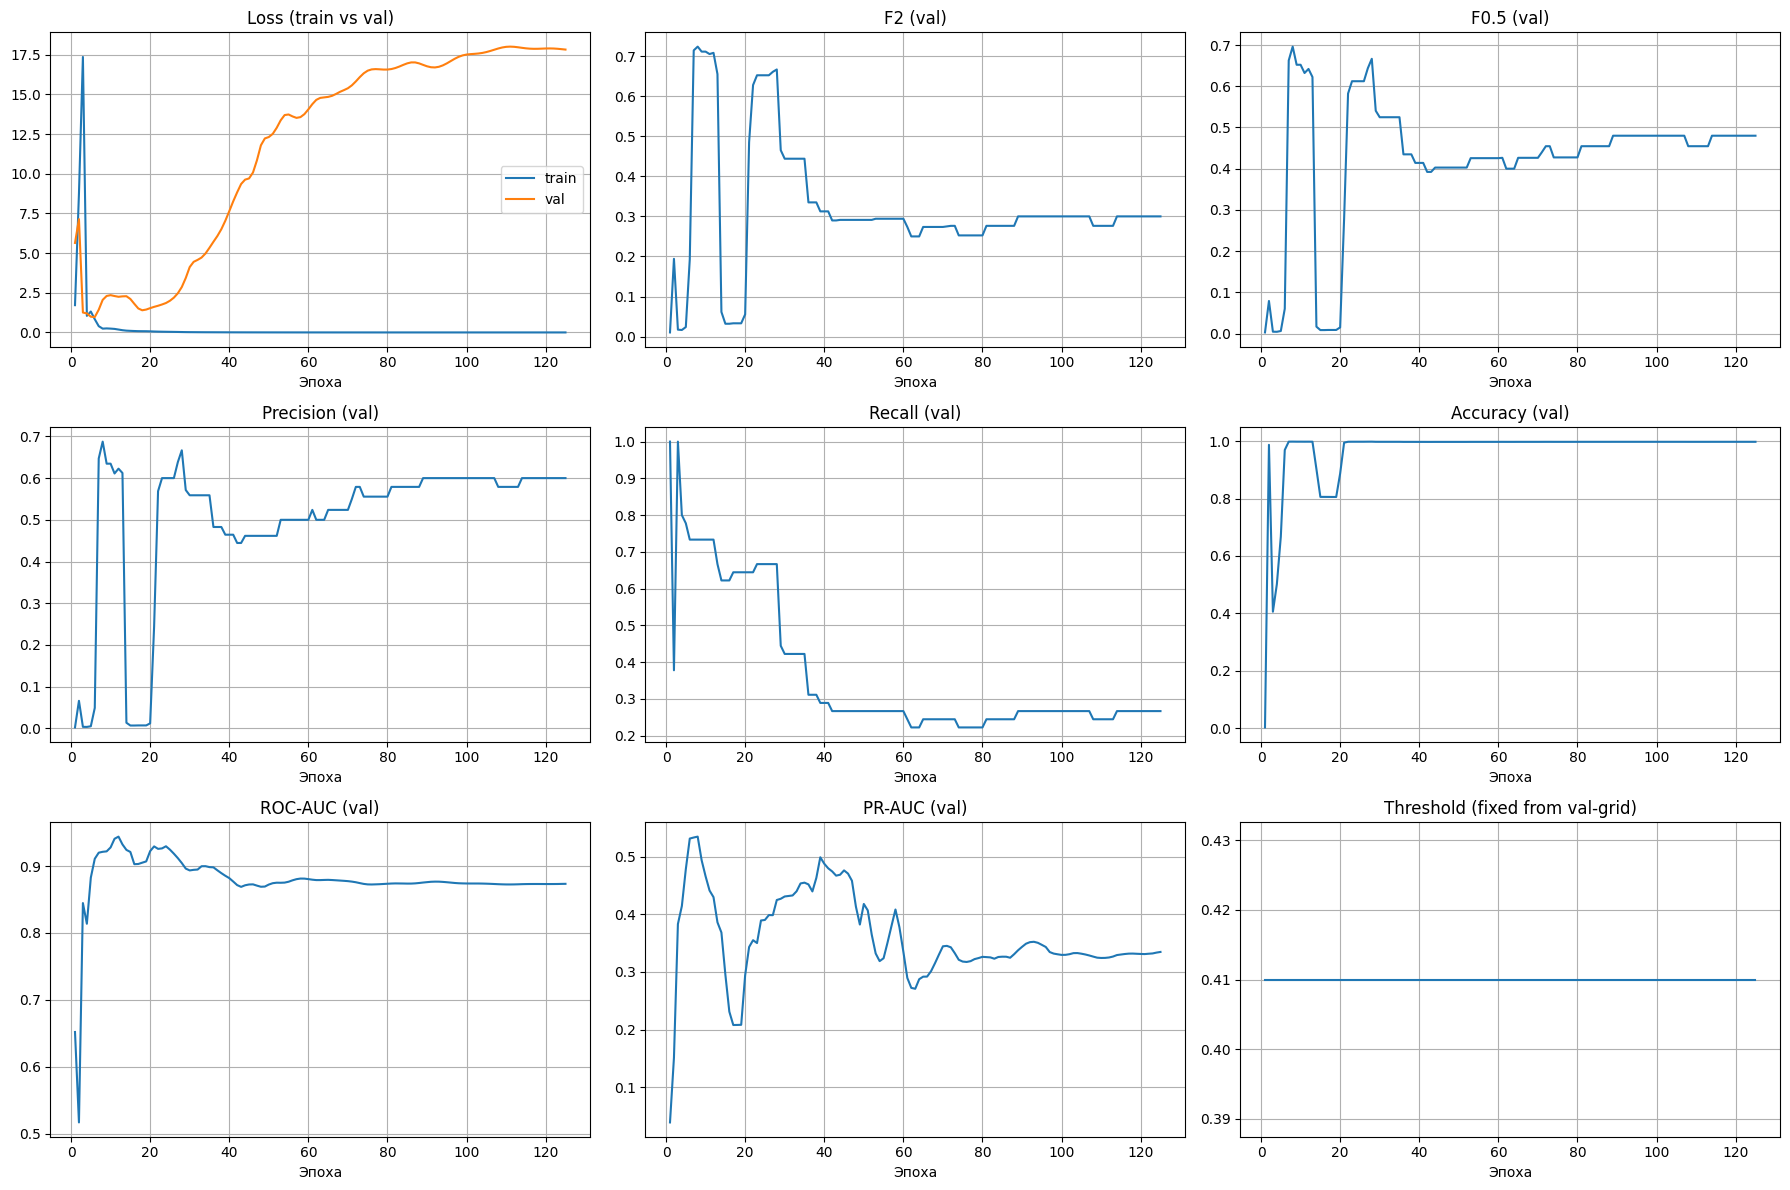


Метрики на уровне транзакций:
  threshold : 0.410000
  F2       : 0.907591
  F0.5     : 0.804094
  Precision: 0.774648
  Recall   : 0.948276
  Accuracy : 0.999034
  ROC-AUC  : 0.997762
  PR-AUC   : 0.859509

Метрики на уровне CustomerId:
  F2       : 0.869565
  F0.5     : 0.816327
  Precision: 0.800000
  Recall   : 0.888889
  Accuracy : 0.995995
  ROC-AUC  : 0.929880
  PR-AUC   : 0.797811


In [9]:
cat_cardinalities_best = [len(best_pair["enc"].cat_maps[c]) for c in CAT_COLS]

model_best = FraudTreeModel(
    cat_cardinalities=cat_cardinalities_best,
    node_raw_dim=1,
    num_dim=len(NUM_COLS),
    time_dim=2,
    hidden=hidden,
    gnn_layers=gnn_layers
).to(device)

model_best.load_state_dict({k: v.to(device) for k, v in best_pair["state"].items()})

thr_best = float(best_pair["thr"])
y_val_np = best_pair["y_val_np"]
hist_raw = best_pair["history_raw"]

history = {
    "train_loss": hist_raw["train_loss"],
    "val_loss": hist_raw["val_loss"],
    "val_ROC-AUC": hist_raw["val_ROC-AUC"],
    "val_PR-AUC": hist_raw["val_PR-AUC"],
    "val_thr_used": [thr_best] * len(hist_raw["val_loss"]),
    "val_F2": [],
    "val_F0.5": [],
    "val_Precision": [],
    "val_Recall": [],
    "val_Accuracy": [],
}

for prob_va in hist_raw["val_prob_by_epoch"]:
    m = compute_metrics_np(y_val_np, prob_va, threshold=thr_best)
    history["val_F2"].append(m["F2"])
    history["val_F0.5"].append(m["F0.5"])
    history["val_Precision"].append(m["Precision"])
    history["val_Recall"].append(m["Recall"])
    history["val_Accuracy"].append(m["Accuracy"])

plot_val_history(history)

scored_test = eval_model_on_test(model_best, best_pair["enc"], df_test, graph_test, device=device)

df_test_merged = df_test.merge(
    scored_test[[ID_COL, "fraud_prob"]],
    on=ID_COL, how="left", validate="one_to_one"
)

if df_test_merged["fraud_prob"].isna().any():
    raise ValueError("Есть TransactionId без fraud_prob после merge")

df_test_merged["fraud_pred"] = (df_test_merged["fraud_prob"] >= thr_best).astype("int64")

tx_metrics = compute_metrics_np(
    y_true=df_test_merged[Y_COL].astype(int).values,
    y_prob=df_test_merged["fraud_prob"].astype(float).values,
    threshold=thr_best
)
cust_metrics = compute_customer_level_metrics(df_test_merged, threshold=thr_best)

print("\nМетрики на уровне транзакций:")
print(f"  threshold : {thr_best:.6f}")
for k in ["F2", "F0.5", "Precision", "Recall", "Accuracy", "ROC-AUC", "PR-AUC"]:
    print(f"  {k:9s}: {tx_metrics[k]:.6f}")

print("\nМетрики на уровне CustomerId:")
for k in ["F2", "F0.5", "Precision", "Recall", "Accuracy", "ROC-AUC", "PR-AUC"]:
    print(f"  {k:9s}: {cust_metrics[k]:.6f}")
